In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [85]:
import plotly.express as px
import plotly.graph_objects as go

In [84]:
!pip install -q plotly

In [2]:
!pip install -q reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 19.8 MB/s eta 0:00:00


In [3]:
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph
)

from reportlab.lib.styles import getSampleStyleSheet

In [4]:
from google.colab import files

uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [5]:
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename, encoding='ISO-8859-1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 9994
Columns: 21


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [8]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [9]:
df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994,9994,9994,9994,9994,9994,9994,...,9994.000000,9994,9994,9994,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
unique,NaN,5009,1237,1334,4,793,793,3,1,531,...,NaN,4,1862,3,17,1850,NaN,NaN,NaN,NaN
top,NaN,CA-2017-100111,9/5/2016,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,...,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN,NaN,NaN,NaN
freq,NaN,14,38,35,5968,37,37,5191,9994,915,...,NaN,3203,19,6026,1523,48,NaN,NaN,NaN,NaN
mean,4997.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,55190.379428,NaN,NaN,NaN,NaN,NaN,229.858001,3.789574,0.156203,28.656896
std,2885.163629,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,32063.693350,NaN,NaN,NaN,NaN,NaN,623.245101,2.225110,0.206452,234.260108
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23223.000000,NaN,NaN,NaN,NaN,NaN,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,56430.500000,NaN,NaN,NaN,NaN,NaN,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,90008.000000,NaN,NaN,NaN,NaN,NaN,209.940000,5.000000,0.200000,29.364000


In [10]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [11]:
print(df.dtypes)

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [12]:
print("Total Sales:", df["Sales"].sum())

print("Total Profit:", df["Profit"].sum())

print("Total Orders:", df["Order ID"].nunique())

print("Total Customers:", df["Customer ID"].nunique())

Total Sales: 2297200.8603000003
Total Profit: 286397.0217
Total Orders: 5009
Total Customers: 793


In [13]:
report = f"""
AI Business Intelligence Platform

Dataset Summary

Rows: {df.shape[0]}

Columns: {df.shape[1]}

Total Sales: {df['Sales'].sum():.2f}

Total Profit: {df['Profit'].sum():.2f}

Total Orders: {df['Order ID'].nunique()}

Total Customers: {df['Customer ID'].nunique()}
"""

print(report)


AI Business Intelligence Platform

Dataset Summary

Rows: 9994

Columns: 21

Total Sales: 2297200.86

Total Profit: 286397.02

Total Orders: 5009

Total Customers: 793



In [14]:
with open(
    "dataset_report.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(report)

print("Dataset Report Saved")

Dataset Report Saved


In [15]:
missing_values = df.isnull().sum()

missing_report = pd.DataFrame({
    "Column": missing_values.index,
    "Missing Values": missing_values.values
})

missing_report

,Column,Missing Values
0,Row ID,0
1,Order ID,0
2,Order Date,0
3,Ship Date,0
4,Ship Mode,0
5,Customer ID,0
6,Customer Name,0
7,Segment,0
8,Country,0
9,City,0


In [16]:
print(
    "Total Missing Values:",
    df.isnull().sum().sum()
)

Total Missing Values: 0


In [17]:
duplicates = df.duplicated().sum()

print(
    "Duplicate Records:",
    duplicates
)

Duplicate Records: 0


In [18]:
df = df.drop_duplicates()

print(
    "New Shape:",
    df.shape
)

New Shape: (9994, 21)


In [19]:
dtype_report = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values
})

dtype_report

,Column,Data Type
0,Row ID,int64
1,Order ID,object
2,Order Date,object
3,Ship Date,object
4,Ship Mode,object
5,Customer ID,object
6,Customer Name,object
7,Segment,object
8,Country,object
9,City,object


In [20]:
unique_report = pd.DataFrame({
    "Column": df.columns,
    "Unique Values":
    [df[col].nunique()
     for col in df.columns]
})

unique_report

,Column,Unique Values
0,Row ID,9994
1,Order ID,5009
2,Order Date,1237
3,Ship Date,1334
4,Ship Mode,4
5,Customer ID,793
6,Customer Name,793
7,Segment,3
8,Country,1
9,City,531


In [21]:
numeric_cols = df.select_dtypes(
    include=["int64", "float64"]
)

numeric_cols.head()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
0,1,42420,261.9600,2,0.00,41.9136
1,2,42420,731.9400,3,0.00,219.5820
2,3,90036,14.6200,2,0.00,6.8714
3,4,33311,957.5775,5,0.45,-383.0310
4,5,33311,22.3680,2,0.20,2.5164


In [22]:
for col in numeric_cols.columns:

    q1 = df[col].quantile(0.25)

    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr

    upper = q3 + 1.5 * iqr

    outliers = df[
        (df[col] < lower)
        |
        (df[col] > upper)
    ]

    print(
        f"{col}: {len(outliers)} outliers"
    )

Row ID: 0 outliers
Postal Code: 0 outliers
Sales: 1167 outliers
Quantity: 170 outliers
Discount: 856 outliers
Profit: 1881 outliers


In [23]:
total_cells = (
    df.shape[0]
    *
    df.shape[1]
)

missing_cells = (
    df.isnull().sum().sum()
)

quality_score = (
    (total_cells - missing_cells)
    /
    total_cells
) * 100

print(
    f"Data Quality Score: "
    f"{quality_score:.2f}%"
)

Data Quality Score: 100.00%


In [24]:
quality_report = f"""
AI Business Intelligence Platform

DATA QUALITY REPORT

Rows:
{df.shape[0]}

Columns:
{df.shape[1]}

Missing Values:
{df.isnull().sum().sum()}

Duplicate Records:
{duplicates}

Data Quality Score:
{quality_score:.2f}%
"""

print(quality_report)


AI Business Intelligence Platform

DATA QUALITY REPORT

Rows:
9994

Columns:
21

Missing Values:
0

Duplicate Records:
0

Data Quality Score:
100.00%



In [25]:
with open(
    "data_quality_report.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(
        quality_report
    )

print(
    "Data Quality Report Saved"
)

Data Quality Report Saved


In [26]:
df.to_csv(
    "cleaned_superstore.csv",
    index=False
)

print(
    "Clean Dataset Saved"
)

Clean Dataset Saved


In [27]:
sales_by_category = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(sales_by_category)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


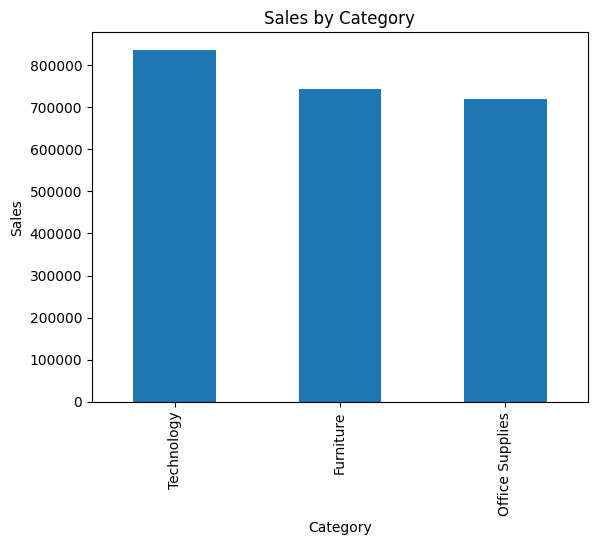

In [28]:
sales_by_category.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

In [29]:
profit_by_category = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print(profit_by_category)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


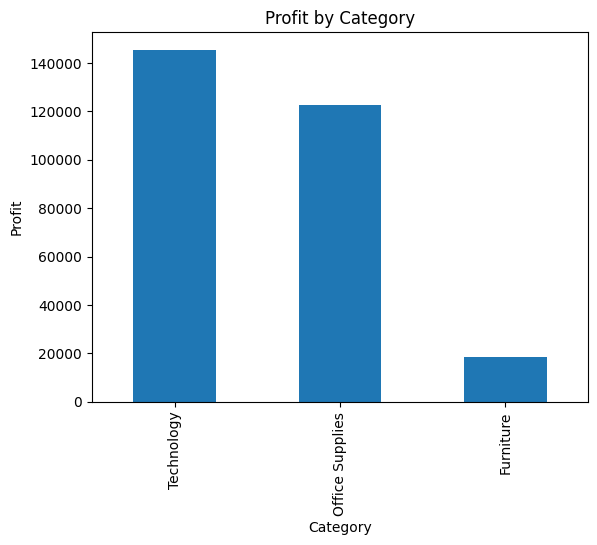

In [30]:
profit_by_category.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()

In [31]:
sales_region = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(sales_region)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


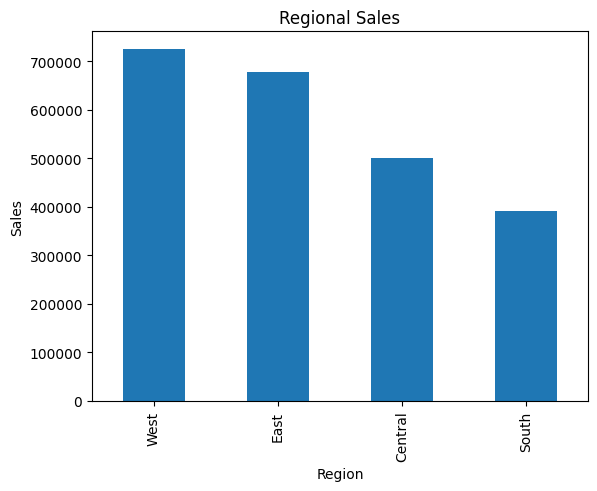

In [32]:
sales_region.plot(kind="bar")

plt.title("Regional Sales")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

In [33]:
profit_region = (
    df.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print(profit_region)

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


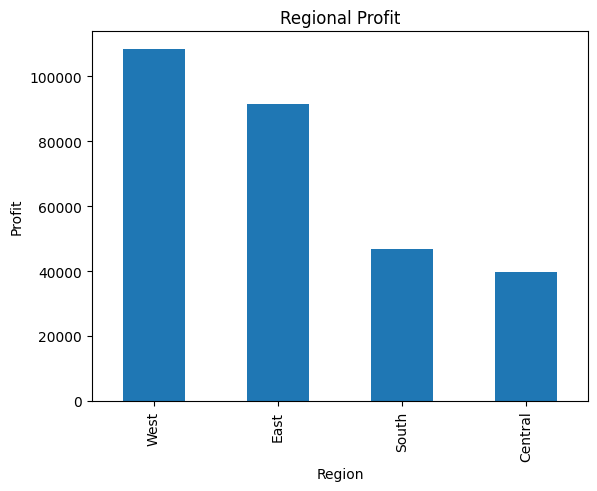

In [34]:
profit_region.plot(kind="bar")

plt.title("Regional Profit")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.show()

In [35]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [36]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


In [37]:
segment_sales = (
    df.groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(segment_sales)

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64


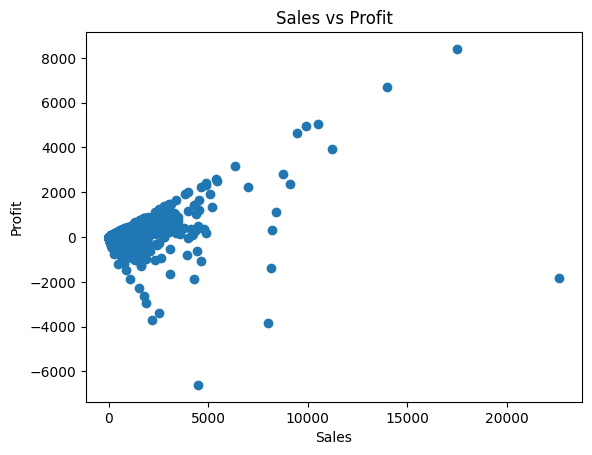

In [38]:
plt.scatter(
    df["Sales"],
    df["Profit"]
)

plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Sales vs Profit")

plt.show()

In [39]:
top_category = sales_by_category.idxmax()

top_region = sales_region.idxmax()

top_customer = top_customers.index[0]

insights = f"""
BUSINESS INSIGHTS

Top Sales Category:
{top_category}

Top Region:
{top_region}

Top Customer:
{top_customer}

Total Sales:
{df['Sales'].sum():.2f}

Total Profit:
{df['Profit'].sum():.2f}
"""

print(insights)


BUSINESS INSIGHTS

Top Sales Category:
Technology

Top Region:
West

Top Customer:
Sean Miller

Total Sales:
2297200.86

Total Profit:
286397.02



In [40]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"]
)

In [41]:
df["Year"] = (
    df["Order Date"]
    .dt.year
)

df["Month"] = (
    df["Order Date"]
    .dt.month
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10


In [42]:
monthly_sales = (
    df.groupby(
        ["Year", "Month"]
    )["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Year,Month,Sales
0,2014,1,14236.895
1,2014,2,4519.892
2,2014,3,55691.009
3,2014,4,28295.345
4,2014,5,23648.287


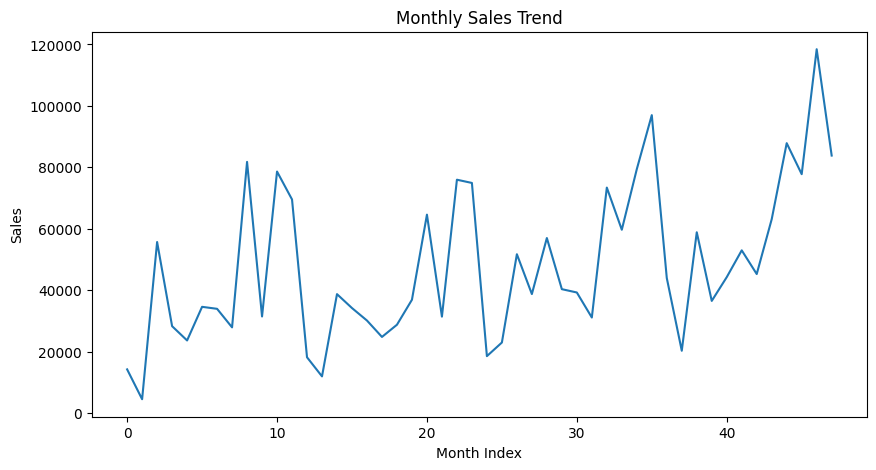

In [43]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales["Sales"]
)

plt.title(
    "Monthly Sales Trend"
)

plt.xlabel("Month Index")

plt.ylabel("Sales")

plt.show()

In [44]:
monthly_profit = (
    df.groupby(
        ["Year", "Month"]
    )["Profit"]
    .sum()
    .reset_index()
)

monthly_profit.head()

,Year,Month,Profit
0,2014,1,2450.1907
1,2014,2,862.3084
2,2014,3,498.7299
3,2014,4,3488.8352
4,2014,5,2738.7096


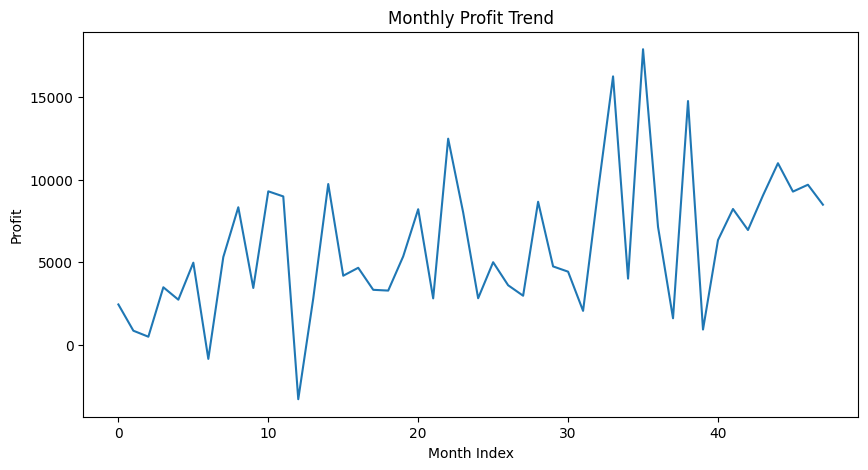

In [45]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_profit["Profit"]
)

plt.title(
    "Monthly Profit Trend"
)

plt.xlabel("Month Index")

plt.ylabel("Profit")

plt.show()

In [46]:
top_states = (
    df.groupby("State")["Sales"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

print(top_states)

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64


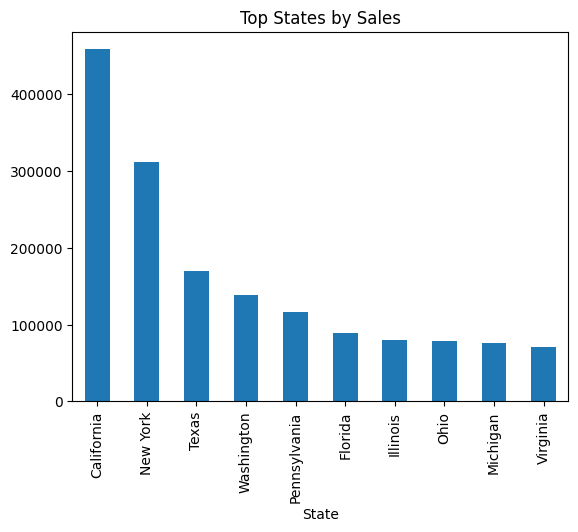

In [47]:
top_states.plot(
    kind="bar"
)

plt.title(
    "Top States by Sales"
)

plt.show()

In [48]:
total_sales = (
    df["Sales"].sum()
)

total_profit = (
    df["Profit"].sum()
)

total_orders = (
    df["Order ID"]
    .nunique()
)

avg_order_value = (
    total_sales
    /
    total_orders
)

print(
    f"Total Sales: {total_sales:.2f}"
)

print(
    f"Total Profit: {total_profit:.2f}"
)

print(
    f"Total Orders: {total_orders}"
)

print(
    f"Average Order Value: {avg_order_value:.2f}"
)

Total Sales: 2297200.86
Total Profit: 286397.02
Total Orders: 5009
Average Order Value: 458.61


In [49]:
best_category = (
    df.groupby("Category")
    ["Sales"]
    .sum()
    .idxmax()
)

print(
    "Best Category:",
    best_category
)

Best Category: Technology


In [50]:
best_region = (
    df.groupby("Region")
    ["Sales"]
    .sum()
    .idxmax()
)

print(
    "Best Region:",
    best_region
)

Best Region: West


In [51]:
executive_summary = f"""
EXECUTIVE SUMMARY

Total Sales:
{total_sales:.2f}

Total Profit:
{total_profit:.2f}

Total Orders:
{total_orders}

Average Order Value:
{avg_order_value:.2f}

Best Performing Category:
{best_category}

Best Performing Region:
{best_region}
"""

print(
    executive_summary
)


EXECUTIVE SUMMARY

Total Sales:
2297200.86

Total Profit:
286397.02

Total Orders:
5009

Average Order Value:
458.61

Best Performing Category:
Technology

Best Performing Region:
West



In [52]:
with open(
    "executive_summary.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(
        executive_summary
    )

print(
    "Executive Summary Saved"
)

Executive Summary Saved


In [53]:
!pip install -q google-generativeai

In [54]:
import google.generativeai as genai

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [55]:
API_KEY = "AQ.Ab8RN6JdQ9ZR4RVdW9E_IGXWm8m55C6kM8OGmrQ6xXXmKAQ7tg"

genai.configure(api_key=API_KEY)

In [56]:
model = genai.GenerativeModel(
    "gemini-2.5-flash"
)

print("Gemini Connected Successfully!")

Gemini Connected Successfully!


In [57]:
dataset_summary = f"""
Business Dataset Summary

Total Sales:
{df['Sales'].sum():.2f}

Total Profit:
{df['Profit'].sum():.2f}

Total Orders:
{df['Order ID'].nunique()}

Total Customers:
{df['Customer ID'].nunique()}

Top Category:
{best_category}

Top Region:
{best_region}
"""

print(dataset_summary)


Business Dataset Summary

Total Sales:
2297200.86

Total Profit:
286397.02

Total Orders:
5009

Total Customers:
793

Top Category:
Technology

Top Region:
West



In [58]:
prompt = f"""
You are an experienced Business Intelligence Analyst.

Based on the following dataset summary, provide:

1. Executive Summary
2. Key Business Insights
3. Business Risks
4. Opportunities
5. Recommendations
6. Action Plan

Dataset Summary:

{dataset_summary}
"""

In [59]:
response = model.generate_content(prompt)

ai_insights = response.text

print(ai_insights)

As an experienced Business Intelligence Analyst, I've analyzed the provided dataset summary to offer a strategic overview of the business's performance.

---

## Business Performance Report

**Date:** October 26, 2023
**Prepared For:** Senior Leadership Team

### 1. Executive Summary

The business demonstrates a solid financial foundation with over \$2.29 million in total sales and a healthy profit of \$286K, resulting in a commendable profit margin of approximately 12.46%. The company serves a highly engaged customer base of 793, generating over 5,000 orders, indicating strong customer loyalty and repeat business. The "Technology" category and the "West" region are clear top performers, acting as significant drivers of revenue and profit. While performance is strong in key areas, the concentration of success also presents specific risks and opportunities for strategic growth and diversification.

---

### 2. Key Business Insights

*   **Healthy Profitability:** With Total Sales of \$2

In [60]:
with open(
    "ai_business_insights.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(ai_insights)

print("AI Insights Saved")

AI Insights Saved


In [61]:
question = input("Ask a business question: ")

Ask a business question: Roi?


In [62]:
qa_prompt = f"""
Dataset Summary:

{dataset_summary}

Question:

{question}

Answer like a Senior Business Analyst.
"""

answer = model.generate_content(
    qa_prompt
)

print(answer.text)

To provide a precise Return on Investment (ROI) figure, we typically require the **Total Cost of Investment** (or the cumulative expenditures incurred to generate these sales and profits) in addition to the Total Profit.

From the provided dataset, we have:
*   **Total Profit:** 286,397.02
*   **Total Sales:** 2,297,200.86

Since the "Cost of Investment" (which would include all operating expenses, capital expenditures, marketing spend, etc.) is not provided, we cannot calculate a true ROI.

However, we can calculate a crucial related profitability metric: the **Net Profit Margin**. This indicates how much profit is generated per dollar of sales.

**Net Profit Margin Calculation:**
Net Profit Margin = (Total Profit / Total Sales) * 100%
Net Profit Margin = (286,397.02 / 2,297,200.86) * 100%
Net Profit Margin = 0.12467 * 100%
**Net Profit Margin ≈ 12.47%**

**Interpretation from a Senior Business Analyst Perspective:**

1.  **Missing Data for True ROI:** Without the specific "investment

In [63]:
swot_prompt = f"""
Perform a SWOT Analysis for this business.

Dataset Summary:

{dataset_summary}
"""

swot = model.generate_content(
    swot_prompt
)

print(swot.text)

Here's a SWOT analysis for your business, based on the provided dataset summary:

## SWOT Analysis: Business Dataset Summary

**Strengths (Internal - Positive Attributes)**

*   **Strong Profitability:** A total profit of $286,397.02 on sales of $2,297,200.86 indicates a healthy profit margin (approx. 12.47%), demonstrating efficient operations and effective pricing strategies.
*   **Significant Sales Volume:** Over $2.2 million in sales shows a substantial market presence and revenue generation capability.
*   **High Customer Loyalty/Repeat Business:** With 5009 orders from only 793 customers, the business averages over 6 orders per customer. This indicates strong customer retention, satisfaction, and a valuable loyal customer base.
*   **Dominance in a High-Value Category (Technology):** Technology is often a sector with high growth potential, innovation, and frequently higher-ticket items, which contributes to the significant sales and profit figures.
*   **Established Market Presen

In [64]:
with open(
    "swot_analysis.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(swot.text)

print("SWOT Analysis Saved")

SWOT Analysis Saved


In [65]:
report_prompt = f"""
You are a Senior Business Intelligence Consultant.

Generate a professional Executive Business Report.

Include:

1. Executive Summary

2. Sales Performance

3. Profit Analysis

4. Customer Analysis

5. Regional Performance

6. Business Risks

7. Growth Opportunities

8. Recommendations

Dataset Summary:

{dataset_summary}
"""

In [66]:
report_response = model.generate_content(
    report_prompt
)

executive_report = report_response.text

print(executive_report)

# Executive Business Report: Q[X] Performance Review

**Prepared For:** Executive Leadership Team
**Prepared By:** [Your Name/Senior Business Intelligence Consultant Team]
**Date:** October 26, 2023
**Period:** [Specify the reporting period, e.g., "FY2023", "Q3 2023"]

---

## 1. Executive Summary

This report provides a comprehensive overview of the company's performance, highlighting key operational metrics, profitability drivers, customer insights, and regional contributions. The business has demonstrated robust overall performance, generating **$2,297,200.86 in Total Sales** and a healthy **$286,397.02 in Total Profit** across 5,009 orders from 793 distinct customers.

The **Technology category** and the **West region** are identified as the primary drivers of this success, showcasing strong market penetration and customer engagement. While these areas represent significant strengths, the analysis also points to potential risks associated with over-reliance on these segments and hi

In [67]:
with open(
    "executive_business_report.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(executive_report)

print("Executive Report Saved")

Executive Report Saved


In [68]:
styles = getSampleStyleSheet()

doc = SimpleDocTemplate(
    "executive_business_report.pdf"
)

story = []

story.append(
    Paragraph(
        executive_report.replace("\n", "<br/>"),
        styles["BodyText"]
    )
)

doc.build(story)

print("PDF Report Created")

PDF Report Created


In [69]:
kpi_prompt = f"""
Generate a KPI Report.

Include:

- Total Sales
- Total Profit
- Average Order Value
- Best Category
- Best Region
- Business Health Score

Dataset Summary:

{dataset_summary}
"""

In [70]:
kpi_response = model.generate_content(
    kpi_prompt
)

kpi_report = kpi_response.text

print(kpi_report)

# KPI Performance Report

**Date:** October 26, 2023

---

## Executive Summary

This report provides a concise overview of key performance indicators based on the latest available business data. The business demonstrates strong overall health, driven by significant sales and robust profitability. The 'Technology' category and the 'West' region are identified as top performers, indicating clear areas of strength. The average order value suggests a healthy per-transaction revenue.

---

## Key Performance Indicators (KPIs)

### 1. Total Sales

*   **Value:** **$2,297,200.86**
*   **Insight:** Represents the gross revenue generated, indicating a very strong overall sales performance and significant market activity.

### 2. Total Profit

*   **Value:** **$286,397.02**
*   **Insight:** Reflects the net earnings after all costs. This demonstrates a healthy profit margin and efficient cost management relative to the sales volume.

### 3. Average Order Value (AOV)

*   **Calculation:** Total 

In [71]:
with open(
    "kpi_report.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(kpi_report)

print("KPI Report Saved")

KPI Report Saved


In [72]:
board_prompt = f"""
Prepare a one-page Board Meeting Summary.

Include:

Business Performance

Major Risks

Growth Areas

Future Strategy

Dataset Summary:

{dataset_summary}
"""

In [73]:
board_response = model.generate_content(
    board_prompt
)

board_summary = board_response.text

print(board_summary)

## Board Meeting Summary

**Date:** October 26, 2023
**Prepared For:** The Board of Directors
**Subject:** Q3 Performance Overview & Strategic Outlook

---

This summary outlines our strong performance in the recent period, highlighting key operational metrics, identifying major risks, pinpointing strategic growth areas, and proposing a future strategy to ensure sustained success.

### Business Performance

We are pleased to report a robust performance across key metrics, demonstrating strong market demand and effective operational execution.

*   **Total Sales:** **$2,297,200.86** – Exceeding the $2.2 million mark, indicating significant market traction.
*   **Total Profit:** **$286,397.02** – Reflecting a healthy profit margin of approximately 12.5% on sales, showcasing efficient cost management and strong pricing strategies.
*   **Total Orders:** **5,009** – A substantial volume of transactions, underscoring our operational capacity and customer engagement.
*   **Total Customers:** 

In [74]:
with open(
    "board_meeting_summary.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(board_summary)

print("Board Summary Saved")

Board Summary Saved


In [75]:
dataset_context = f"""
Business Dataset Summary

Rows:
{df.shape[0]}

Columns:
{list(df.columns)}

Total Sales:
{df['Sales'].sum():.2f}

Total Profit:
{df['Profit'].sum():.2f}

Top Categories

{sales_by_category}

Top Regions

{sales_region}

Top Customers

{top_customers}

Segment Sales

{segment_sales}
"""

print(dataset_context)


Business Dataset Summary

Rows:
9994

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year', 'Month']

Total Sales:
2297200.86

Total Profit:
286397.02

Top Categories

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

Top Regions

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

Top Customers

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant 

In [76]:
def chat_with_dataset(question):

    prompt = f"""
You are a Senior Business Intelligence Analyst.

Dataset Information:

{dataset_context}

User Question:

{question}

Answer professionally.

If appropriate:

• Explain reasoning

• Give business insight

• Suggest actions
"""

    response = model.generate_content(prompt)

    return response.text

In [77]:
question = "Which region contributes the highest revenue?"

answer = chat_with_dataset(question)

print(answer)

Based on the provided dataset summary, the **West region** contributes the highest revenue.

**Reasoning:**

From the "Top Regions" breakdown, we can clearly see the sales figures for each region:

*   **West: 725,457.82**
*   East: 678,781.24
*   Central: 501,239.89
*   South: 391,721.90

The West region's total sales of **$725,457.82** are greater than any other region, making it the highest revenue contributor.

**Business Insight:**

The West region is a clear leader in terms of revenue generation, outperforming the next closest region (East) by approximately $46,676. This indicates a strong market presence, effective sales operations, or potentially a larger customer base and higher purchasing power within this geographic area. Understanding the factors driving this success is crucial for strategic planning.

**Suggested Actions:**

1.  **Deep Dive Analysis:** Conduct further analysis into the West region to identify the specific drivers of its high performance. This could include

In [78]:
while True:

    user_question = input("Ask a business question (type exit to stop): ")

    if user_question.lower() == "exit":
        break

    print("\nAI Answer\n")

    print(chat_with_dataset(user_question))

    print("\n")

Ask a business question (type exit to stop): Roi ?

AI Answer



ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1896.92ms


As a Senior Business Intelligence Analyst, I understand you're asking about "ROI" (Return on Investment).

**Explanation:**

Return on Investment (ROI) is a critical metric used to evaluate the efficiency and profitability of an investment. It is typically calculated as:

$$ ROI = \frac{(Net Profit - Cost\ of\ Investment)}{Cost\ of\ Investment} \times 100\% $$

Or, more broadly:

$$ ROI = \frac{Net\ Profit}{Total\ Costs} \times 100\% $$

From the provided dataset summary, we have:

*   **Total Sales:** \$2,297,200.86
*   **Total Profit:** \$286,397.02

However, the dataset summary **does not provide a direct measure for "Cost of Investment" or "Total Costs" (e.g., Cost of Goods Sold, operating expenses, marketing spend, capital investment).** Without this crucial cost component, a precise calculation of traditional ROI is not possible.

**Alternative & Related Metric: Profit Margin**

While we cannot calculate a direct ROI, we can determine the **Overall Profit Margin**, which indicate

In [79]:
conversation = []

while True:

    q = input("Question (exit to finish): ")

    if q.lower() == "exit":
        break

    a = chat_with_dataset(q)

    conversation.append(
        f"Question:\n{q}\n\nAnswer:\n{a}\n\n"
    )

    print(a)

Question (exit to finish): roi?
The user is asking for "ROI" (Return on Investment).

As a Senior Business Intelligence Analyst, I must clarify that a direct calculation of **Return on Investment (ROI)** cannot be performed with the current dataset summary alone. ROI typically requires knowing a specific "Investment Cost" against which the net profit is measured. For example, the cost of a marketing campaign, a new product development, or a capital expenditure.

The provided dataset contains 'Sales' and 'Profit', which allows us to calculate **Profit Margin**, a crucial indicator of operational profitability. Profit Margin is often confused with ROI but serves a different purpose, showing how much profit is generated per dollar of sales.

Let's break down what we *can* calculate and how it relates to your underlying interest in profitability:

### Profit Margin Calculation

Profit Margin measures how much profit a company makes for every dollar of sales.

*   **Total Profit:** $286,397

In [80]:
with open(
    "conversation_history.txt",
    "w",
    encoding="utf-8"
) as file:

    for item in conversation:

        file.write(item)

print("Conversation Saved")

Conversation Saved


In [81]:
recommendation_prompt = f"""
Based on the dataset below,

Generate

1. Five Business Recommendations

2. Five Cost Reduction Ideas

3. Five Growth Strategies

Dataset

{dataset_context}
"""

recommendations = model.generate_content(
    recommendation_prompt
)

print(recommendations.text)

Here are five business recommendations, five cost reduction ideas, and five growth strategies based on the provided dataset summary:

---

### 1. Five Business Recommendations

1.  **Deep Dive into Category Profitability:** While Technology, Furniture, and Office Supplies are the top categories by sales, their individual profit margins are unknown. Conduct a detailed analysis to identify which sub-categories or specific products within these top categories are most profitable (and least profitable) to inform inventory, marketing, and pricing strategies.
2.  **Strategic Regional Investment and Analysis:** Investigate the reasons behind the significantly lower sales in the 'South' region compared to West, East, and Central. This could involve market research, competitive analysis, or an assessment of local demand to determine if it's an untapped growth opportunity or an area with specific challenges requiring a unique approach.
3.  **Develop Robust Customer Loyalty & Retention Programs:*

In [82]:
with open(
    "business_recommendations.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(recommendations.text)

print("Recommendations Saved")

Recommendations Saved


In [83]:
health_prompt = f"""
Give this company a Business Health Score out of 100.

Explain why.

Dataset

{dataset_context}
"""

health = model.generate_content(
    health_prompt
)

print(health.text)

**Business Health Score: 82/100**

**Explanation:**

This company demonstrates a very healthy and stable business profile, primarily driven by strong profitability and exceptional diversification across its operations.

**Strengths (Contributing to a high score):**

1.  **Strong Profitability:**
    *   Total Sales: \$2,297,200.86
    *   Total Profit: \$286,397.02
    *   **Profit Margin: (286,397.02 / 2,297,200.86) * 100 = 12.47%**
    *   A profit margin of nearly 12.5% is robust and indicates efficient operations and good pricing power, which is a key indicator of business health.

2.  **Excellent Revenue Diversification:**
    *   **By Category:** Sales are well-distributed across Technology, Furniture, and Office Supplies, preventing over-reliance on any single product line.
    *   **By Region:** A healthy spread of sales across West, East, Central, and South regions suggests a broad market presence and reduces geographic risk.
    *   **By Customer:** The top customer (Sean Mil

In [86]:
print("=" * 50)
print("BUSINESS INTELLIGENCE DASHBOARD")
print("=" * 50)

print(f"Total Sales       : ${df['Sales'].sum():,.2f}")
print(f"Total Profit      : ${df['Profit'].sum():,.2f}")
print(f"Total Orders      : {df['Order ID'].nunique()}")
print(f"Total Customers   : {df['Customer ID'].nunique()}")
print(f"Average Order     : ${df['Sales'].mean():,.2f}")

print("=" * 50)

BUSINESS INTELLIGENCE DASHBOARD
Total Sales       : $2,297,200.86
Total Profit      : $286,397.02
Total Orders      : 5009
Total Customers   : 793
Average Order     : $229.86


In [87]:
sales_category = (
    df.groupby("Category")["Sales"]
    .sum()
    .reset_index()
)

fig = px.bar(
    sales_category,
    x="Category",
    y="Sales",
    title="Sales by Category"
)

fig.show()

In [88]:
profit_category = (
    df.groupby("Category")["Profit"]
    .sum()
    .reset_index()
)

fig = px.bar(
    profit_category,
    x="Category",
    y="Profit",
    title="Profit by Category"
)

fig.show()

In [89]:
sales_region_df = (
    df.groupby("Region")["Sales"]
    .sum()
    .reset_index()
)

fig = px.pie(
    sales_region_df,
    names="Region",
    values="Sales",
    title="Regional Sales Distribution"
)

fig.show()

In [90]:
segment_df = (
    df.groupby("Segment")["Sales"]
    .sum()
    .reset_index()
)

fig = px.bar(
    segment_df,
    x="Segment",
    y="Sales",
    title="Sales by Customer Segment"
)

fig.show()

In [91]:
monthly_sales = (
    df.groupby(
        ["Year", "Month"]
    )["Sales"]
    .sum()
    .reset_index()
)

fig = px.line(
    monthly_sales,
    x="Month",
    y="Sales",
    color="Year",
    markers=True,
    title="Monthly Sales Trend"
)

fig.show()

In [92]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .nlargest(10)
    .reset_index()
)

fig = px.bar(
    top_products,
    x="Sales",
    y="Product Name",
    orientation="h",
    title="Top 10 Products by Sales"
)

fig.show()

In [93]:
fig = px.scatter(
    df,
    x="Sales",
    y="Profit",
    color="Category",
    hover_data=["Product Name"],
    title="Sales vs Profit"
)

fig.show()

In [94]:
fig = px.histogram(
    df,
    x="Profit",
    nbins=40,
    title="Profit Distribution"
)

fig.show()

In [95]:
dashboard_summary = f"""
INTERACTIVE DASHBOARD SUMMARY

Total Sales:
{df['Sales'].sum():,.2f}

Total Profit:
{df['Profit'].sum():,.2f}

Best Category:
{best_category}

Best Region:
{best_region}

Dashboard Generated Successfully.
"""

print(dashboard_summary)


INTERACTIVE DASHBOARD SUMMARY

Total Sales:
2,297,200.86

Total Profit:
286,397.02

Best Category:
Technology

Best Region:
West

Dashboard Generated Successfully.



In [96]:
with open(
    "dashboard_summary.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(dashboard_summary)

print("Dashboard Summary Saved")

Dashboard Summary Saved
